In [1]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv('data/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df['label'].value_counts())
print()
print(df.isnull().sum())

label
ham     4825
spam     747
Name: count, dtype: int64

label    0
text     0
dtype: int64


In [5]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [6]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(4457,) (1115,)


In [7]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(4457, 6275) (1115, 6275)


In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)

print("All models trained.")

All models trained.


In [9]:
nb_preds = nb_model.predict(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)
svm_preds = svm_model.predict(X_test_tfidf)

In [10]:
def evaluate_model(name, y_test, preds):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print()

evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)
evaluate_model("SVM", y_test, svm_preds)

--- Naive Bayes ---
Accuracy: 0.9641255605381166
Precision: 0.990990990990991
Recall: 0.738255033557047
F1 Score: 0.8461538461538461

--- Logistic Regression ---
Accuracy: 0.9650224215246637
Precision: 0.9910714285714286
Recall: 0.7449664429530202
F1 Score: 0.8505747126436781

--- SVM ---
Accuracy: 0.9838565022421525
Precision: 0.9851851851851852
Recall: 0.8926174496644296
F1 Score: 0.9366197183098591



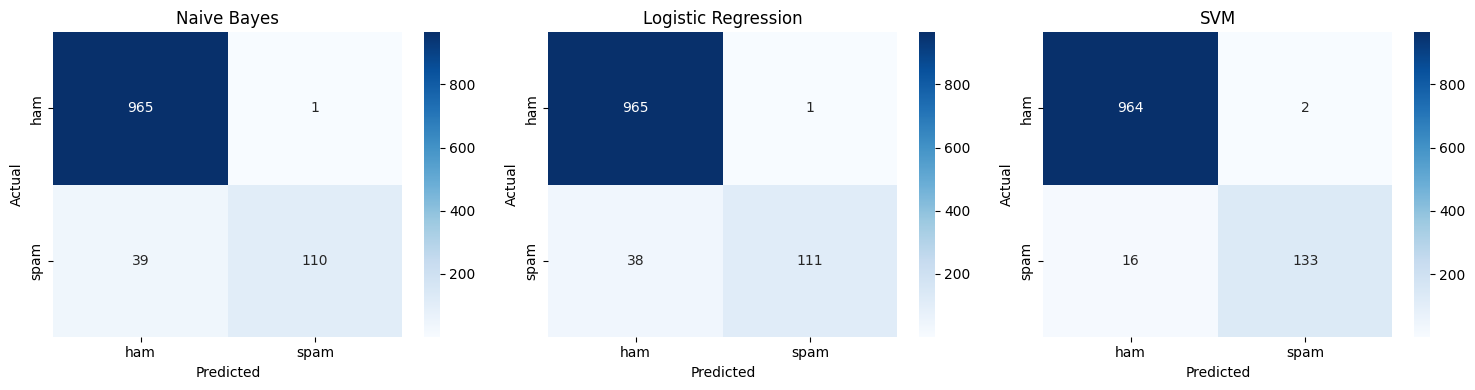

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, [("Naive Bayes", nb_preds), ("Logistic Regression", lr_preds), ("SVM", svm_preds)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [12]:
def predict_message(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = svm_model.predict(vectorized)[0]
    return "Spam" if prediction == 1 else "Ham"

sample_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify your details immediately.",
    "Can you send me the notes from today's class?"
]

for msg in sample_messages:
    print(f"{msg} --> {predict_message(msg)}")

Congratulations! You've won a $1000 Walmart gift card. Click here to claim now! --> Spam
Hey, are we still meeting for lunch tomorrow? --> Ham
URGENT: Your account has been suspended. Verify your details immediately. --> Spam
Can you send me the notes from today's class? --> Ham


In [13]:
tfidf_ngram = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

X_train_tfidf2 = tfidf_ngram.fit_transform(X_train)
X_test_tfidf2 = tfidf_ngram.transform(X_test)

print(X_train_tfidf2.shape, X_test_tfidf2.shape)

(4457, 5000) (1115, 5000)


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']
}

grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_tfidf2, y_train)

print("Best params:", grid_search.best_params_)
print("Best F1 score (cross-val):", grid_search.best_score_)

Best params: {'C': 1, 'kernel': 'linear'}
Best F1 score (cross-val): 0.9331087105953788


In [15]:
final_model = SVC(C=1, kernel='linear', probability=True)
final_model.fit(X_train_tfidf2, y_train)

final_preds = final_model.predict(X_test_tfidf2)

evaluate_model("Final SVM (tuned + ngrams)", y_test, final_preds)

--- Final SVM (tuned + ngrams) ---
Accuracy: 0.9847533632286996
Precision: 0.9925373134328358
Recall: 0.8926174496644296
F1 Score: 0.9399293286219081



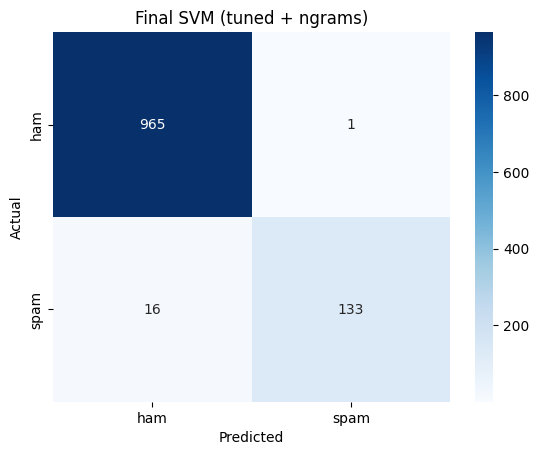

In [16]:
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Final SVM (tuned + ngrams)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': final_preds
})

missed_spam = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 0)]
print(f"Number of missed spam messages: {len(missed_spam)}")
missed_spam

Number of missed spam messages: 16


,text,actual,predicted
44,freemsg hey darl week word back id like fun st...,1,0
165,hi ur lookin sauci daytim fun wiv busti marri ...,1,0
196,ringtonek,1,0
219,sorri miss call let talk time im,1,0
235,latest news polic station toilet stolen cop no...,1,0
418,u get phone wanna chat set meet call u cum mor...,1,0
467,peopl dog area call join like mind guy arrang ...,1,0
478,sale arsen dartboard good condit doubl trebl,1,0
606,email alertfrom jeri stewarts kbsubject lowcos...,1,0
721,freemsgfav xma tonesrepli real,1,0


In [18]:
import joblib

joblib.dump(final_model, 'spam_model.pkl')
joblib.dump(tfidf_ngram, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [19]:
import gradio as gr

def gradio_predict(message):
    cleaned = clean_text(message)
    vectorized = tfidf_ngram.transform([cleaned])
    prediction = final_model.predict(vectorized)[0]
    probability = final_model.predict_proba(vectorized)[0]
    
    label = "Spam" if prediction == 1 else "Ham"
    confidence = probability[prediction] * 100
    
    return f"{label} ({confidence:.2f}% confidence)"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, placeholder="Enter a message to check...", label="Message"),
    outputs=gr.Textbox(label="Prediction"),
    title="Email / SMS Spam Detector",
    description="Enter a message below to check whether it's spam or not. Powered by a tuned SVM model with TF-IDF (1-2 gram) features.",
    examples=[
        ["Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!"],
        ["Hey, are we still meeting for lunch tomorrow?"],
        ["URGENT: Your account has been suspended. Verify your details immediately."],
        ["Can you send me the notes from today's class?"]
    ]
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv
